<h2>Throughout this notebook we present a perpective to gain a deeper understanding on AB tests. Especially on how to visualise alpha, beta, and the p-value. We also provide some mnemotecnics to make AB test much more understandable. <br><br>The intent of this notebook is to explain AB test for anyone to bring him from scratch or not to a rather advanced level on the matter.

In [56]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from scipy.stats import norm

<h2>Here is a simple case: a website test a new button color, we are interested in knowing if the new color (blue) increase the efficiency of the page to convert compared to the current color (red). We choose as main KPI the Conversion Rate. The Conversion Rate tells for 100 visitors how much will convert in average.</h2>

We set our hypotheses: 
- H0: The new button's color does not increase the Conversion Rate.
- H1: The new button's color does increase the Conversion Rate. 

<h3>At the core of an AB test we simply test, provided large enough sample sizes (we can talk about it later in the notebook), the difference of the means in between 2 variants (a variant is a set of samples exposed to one variation of our experiment, in our case sammples are visitors : one variant will be exposed to the red button the other will be exposed to the blue button).</h3>

<h3>Let's say that we find a Conversion Rate (CR) of 3% for the red button and 6% for the red button. We simply look for their difference. We can see the difference from at least two perspectives : we can look at the absolute difference and the relative difference (relative to the current state -- red button)</h3>

<h3>We set our results.</h3>

In [11]:
mean_cr_variant_red = 3
mean_cr_variant_blue = 6

<h3>Below we compute the absolute difference (tested/new/button blue mean CR - control/current/button red mean CR).

In [12]:
mean_cr_variant_blue - mean_cr_variant_red

3

<h3>And the relative difference. That is the ((absolute difference divided by/relative to) / (the current/control/button red value) multiplied by 100 to express it as a percentage.

In [13]:
((mean_cr_variant_blue - mean_cr_variant_red)/mean_cr_variant_red)*100

100.0

<h3>All in all the change of color represents an absolute difference of 3 percentage point in our case which is also a relative difference of +100%. 

<h3>Up until now we have the mean results of our experiment but we still don't have statistically rejected or not our H0 hypothesis.<br><br>
    
This can be a tricky point to understand but from all the possible visitors a website can have (assuming there is a finite number for that) the conversion rates we get might not be the actual Conversion Rate of this whole population (all possible visitors for a website to which we would have submitted a blue button). <br>

Rephrasing the idea: the 6% Conversion Rate we get from the blue button is the conversion rate of the sampled visitors we have and maybe not the real Conversion Rate had we sampled all possible visitors possible for a website. There is always a possibility, from our sampling to have sampled a group that is not representative of the whole population we would like to guess simply "by chance" (assuming no error in the test setup).

<h3>This is where intervene the Central Limit Theorem (yes AB test relies on this theorem). <br><br>
    
The Central Limit Theorem is quite a fascinating Theorem that states that from a population (here all the possible visitors from our website) if we collect the mean of several subgroups (like we did one time with our blue button for instance - CR 6%) iteratively, then all the mean we collected will distribute in such a way that the distribution will approximate a normal distribution. <br>

Let's take a moment to provide some visualisation of the Central Limit Theorem.

<h3>Below we plot the theoretical size of the whole population that we are interested in, that is the total number of visitors possible and to whom we would display the blue button. It can help thinking this ensemble as a theoretical ensemble or an imaginary ensemble.</h3><br>
<h3>In this ensemble we show subsamples possible and the one we got from our experiment in red. It shows that our experiment does not cover all possible visitors hence the fact that 6% of CR might not be the actual CR of the whole population (the blue ensemble/area).</h3>

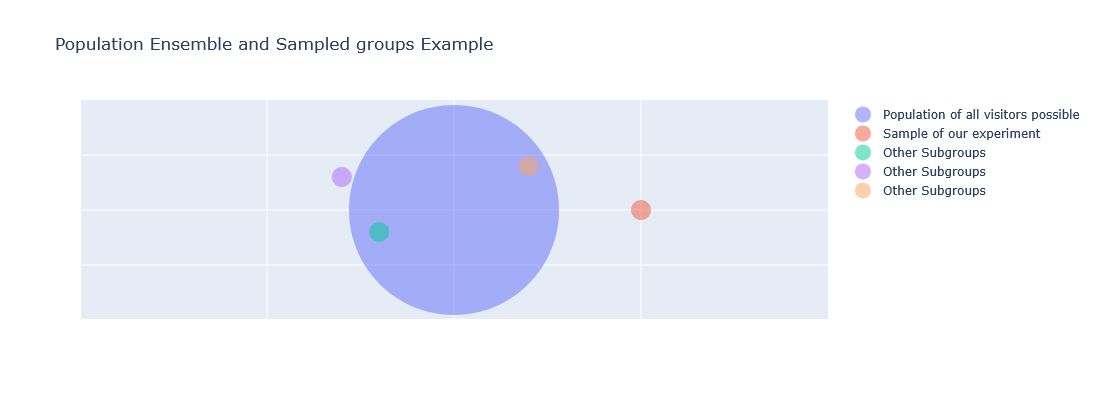

In [49]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=[1], y=[1], mode='markers', name='Population of all visitors possible', marker=dict(size=210, opacity=0.5)))
fig.add_trace(go.Scatter(x=[1.5], y=[1], mode='markers', name='Sample of our experiment', marker=dict(size=20, opacity=0.5)))
fig.add_trace(go.Scatter(x=[0.8], y=[0.8], mode='markers', name='Other Subgroups', marker=dict(size=20, opacity=0.5)))
fig.add_trace(go.Scatter(x=[0.7], y=[1.3], mode='markers', name='Other Subgroups', marker=dict(size=20, opacity=0.5)))
fig.add_trace(go.Scatter(x=[1.2], y=[1.4], mode='markers', name='Other Subgroups', marker=dict(size=20, opacity=0.5)))

fig.update_layout(title='Population Ensemble and Sampled groups Example', width=600, height=400,
                 xaxis=dict(
        title=None,
        range=[0,2],
        showticklabels=False
    ),
    yaxis=dict(
        title=None,
        showticklabels=False,
        range=[0,2]
    )
                 )

fig.show()

<h3>Below we plot the distribution of the mean of our samples.</h3>

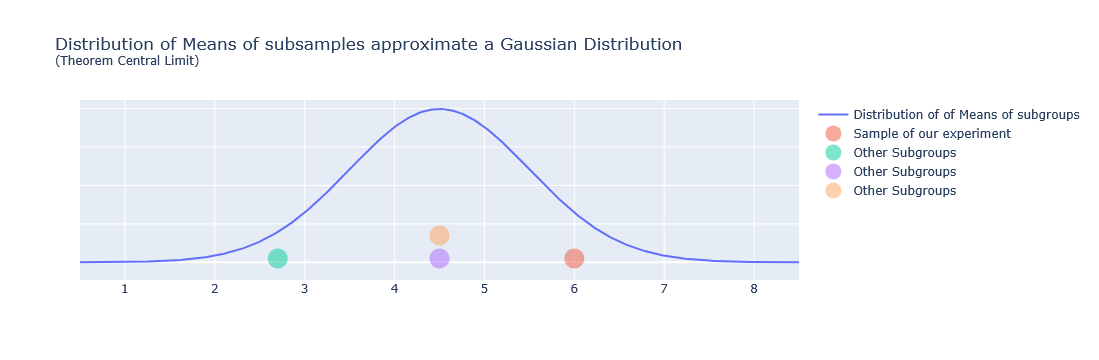

In [83]:
mu = 4.5
sigma = 1

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
y = norm.pdf(x, mu, sigma)


fig = go.Figure()
fig.add_trace(go.Scatter(x=x,y=y,mode='lines',name='Distribution of of Means of subgroups',line=dict(width=2)))
fig.add_trace(go.Scatter(x=[6],y=[0.01],mode='markers',name='Sample of our experiment',marker=dict(size=20, opacity=0.5)))
fig.add_trace(go.Scatter(x=[2.7],y=[0.01],mode='markers',name='Other Subgroups',marker=dict(size=20, opacity=0.5)))
fig.add_trace(go.Scatter(x=[4.5],y=[0.01],mode='markers',name='Other Subgroups',marker=dict(size=20, opacity=0.5)))
fig.add_trace(go.Scatter(x=[4.5],y=[0.07],mode='markers',name='Other Subgroups',marker=dict(size=20, opacity=0.5)))
fig.update_layout(xaxis=dict(title=None),yaxis=dict(title=None,showticklabels=False),width=700, 
                  title='Distribution of Means of subsamples approximate a Gaussian Distribution <br><sup>(Theorem Central Limit)')

fig.show()

<h3>Following the Theorem Central Limit we are now able to infer the distribution of our two variants.</h3>

The standard deviation (standard error) of the conversion rate is:

$$
\text{std}(\hat{p}) = \sqrt{ \frac{ \hat{p}(1 - \hat{p}) }{n} }
$$

Where:
- \( \hat{p} \) is the observed conversion rate (conversions / users)
- \( n \) is the number of users

In [152]:
std_blue = np.sqrt((0.06*(1-0.06))/1000)
std_red = np.sqrt((0.03*(1-0.03))/1000)

In [153]:
std_blue_100 = std_blue*100
std_red_100 = std_red*100

In [154]:
mu_blue = 6

x_blue = np.linspace(mu_blue - 4*std_blue_100, mu_blue + 4*std_blue_100, 500)
y_blue = norm.pdf(x_blue, mu_blue, std_blue_100)

In [155]:
mu_red = 3

x_red = np.linspace(mu_red - 4*std_red_100, mu_red + 4*std_red_100, 500)
y_red = norm.pdf(x_red, mu_red, std_red_100)

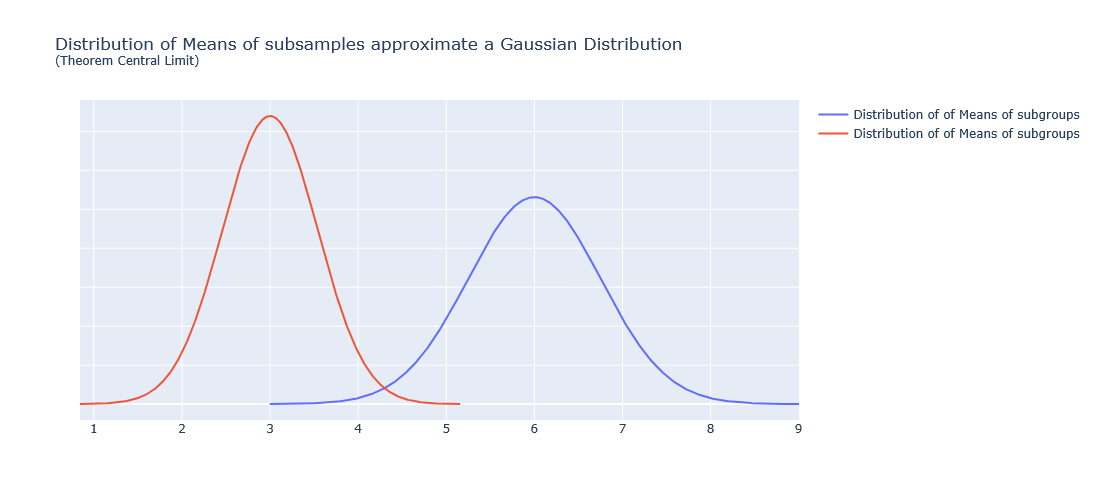

In [156]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=x_blue,y=y_blue,mode='lines',name='Distribution of of Means of subgroups',line=dict(width=2)))
fig.add_trace(go.Scatter(x=x_red,y=y_red,mode='lines',name='Distribution of of Means of subgroups',line=dict(width=2)))

fig.update_layout(xaxis=dict(title=None),yaxis=dict(title=None,showticklabels=False), height=500,
                  title='Distribution of Means of subsamples approximate a Gaussian Distribution <br><sup>(Theorem Central Limit)')

fig.show()

<h3>What interest us is the distribution of the differences.</h3>

In [160]:
mu_diff = mu_blue - mu_red

In [159]:
std_diff = np.sqrt(std_blue**2 + std_red**2)
std_diff_100 = std_diff*100

In [161]:
x_diff = np.linspace(mu_diff - 4*std_diff_100, mu_diff + 4*std_diff_100, 500)
y_diff = norm.pdf(x_diff, mu_diff, std_diff_100)

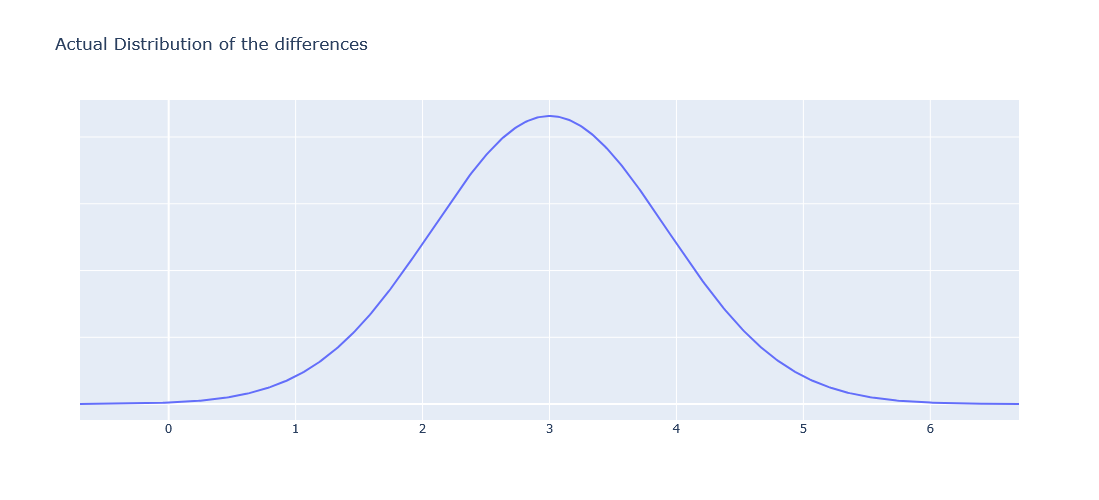

In [169]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=x_diff,y=y_diff,mode='lines',name='Distribution of of Means of subgroups',line=dict(width=2)))

fig.update_layout(xaxis=dict(title=None),yaxis=dict(title=None,showticklabels=False), height=500, width=700,
                  title='Actual Distribution of the differences')

fig.show()

<h3>H0 distribution</h3>

In [182]:
h0_mu = 0
v_a_h0_mu = 3
v_b_h0_mu = 3

h0_std = np.sqrt((0.03*(1-0.03))/1000)
h0_std_100 = h0_std*100

std_diff_h0 = np.sqrt(h0_std**2 + h0_std**2)
std_diff_h0_100 = std_diff_h0*100

In [183]:
x_h0 = np.linspace(h0_mu - 4*h0_std_100, h0_mu + 4*h0_std_100, 500)
y_h0 = norm.pdf(x_h0, h0_mu, h0_std_100)

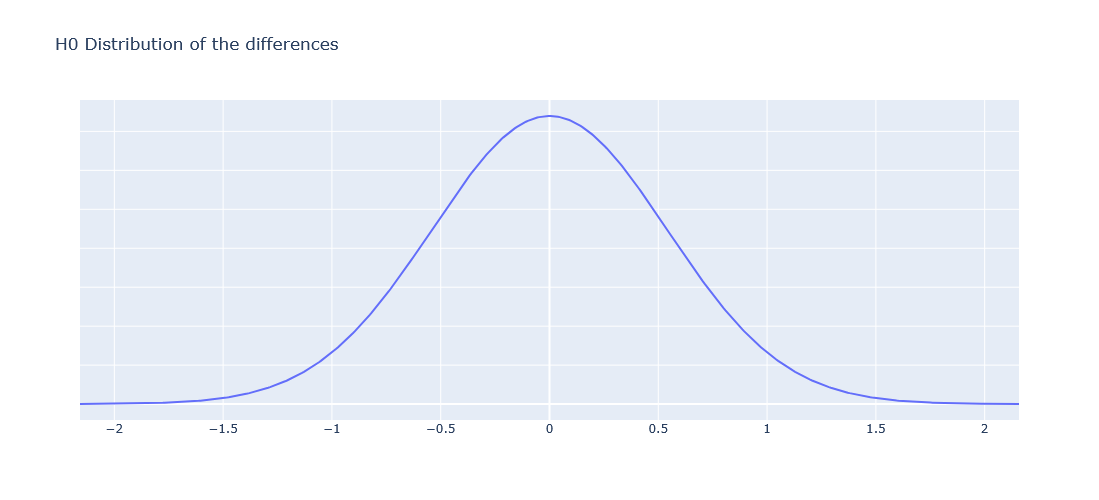

In [184]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=x_h0,y=y_h0,mode='lines',name='Distribution of of Means of subgroups',line=dict(width=2)))

fig.update_layout(xaxis=dict(title=None),yaxis=dict(title=None,showticklabels=False), height=500, width=700,
                  title='H0 Distribution of the differences')

fig.show()

<h3>H1 Distribution</h3>